In [1]:
# =========================================================
# BAGIAN INDHIRA - MODEL NEURAL NETWORK DAN TRAINING
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# =========================================================
# 1. Load Data Hasil Preprocessing
# =========================================================

print("=== MEMULAI TUGAS MODEL TRAINING - INDHIRA ===")

path1 = "processed_data"
path2 = "../processed_data"

if os.path.exists(path1):
    processed_path = path1
elif os.path.exists(path2):
    processed_path = path2
else:
    raise FileNotFoundError(
        "Folder processed_data tidak ditemukan. "
        "Jalankan bagian Khesa terlebih dahulu."
    )

X_train_scaled = pd.read_csv(f"{processed_path}/X_train_scaled.csv")
X_test_scaled = pd.read_csv(f"{processed_path}/X_test_scaled.csv")
y_train = pd.read_csv(f"{processed_path}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{processed_path}/y_test.csv").squeeze()

print("Data hasil preprocessing berhasil dimuat.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

=== MEMULAI TUGAS MODEL TRAINING - INDHIRA ===
Data hasil preprocessing berhasil dimuat.
X_train_scaled: (241, 13)
X_test_scaled : (61, 13)
y_train       : (241,)
y_test        : (61,)


In [3]:
# =========================================================
# 2. Membuat Arsitektur Neural Network
# =========================================================

model = Sequential()

model.add(Dense(
    32,
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

model.add(Dropout(0.2))

model.add(Dense(
    16,
    activation='relu'
))

model.add(Dropout(0.2))

model.add(Dense(
    8,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))

d:\POLINEMA\Semester2\laragon\bin\python\python-3.10\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# =========================================================
# 3. Compile Model
# =========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# =========================================================
# 4. Early Stopping
# =========================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [6]:
# =========================================================
# 5. Training Model
# =========================================================

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6302 - loss: 0.6541 - val_accuracy: 0.5102 - val_loss: 0.6622
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6771 - loss: 0.6222 - val_accuracy: 0.6327 - val_loss: 0.6246
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7292 - loss: 0.5962 - val_accuracy: 0.7347 - val_loss: 0.5834
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7708 - loss: 0.5639 - val_accuracy: 0.7755 - val_loss: 0.5413
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7812 - loss: 0.5295 - val_accuracy: 0.7755 - val_loss: 0.5053
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7760 - loss: 0.4866 - val_accuracy: 0.7959 - val_loss: 0.4707
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7552 - loss: 0.4724 - val_accuracy: 0.7959 - val_loss: 0.4439
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8229 - loss: 0.4295 - val_accuracy: 0.

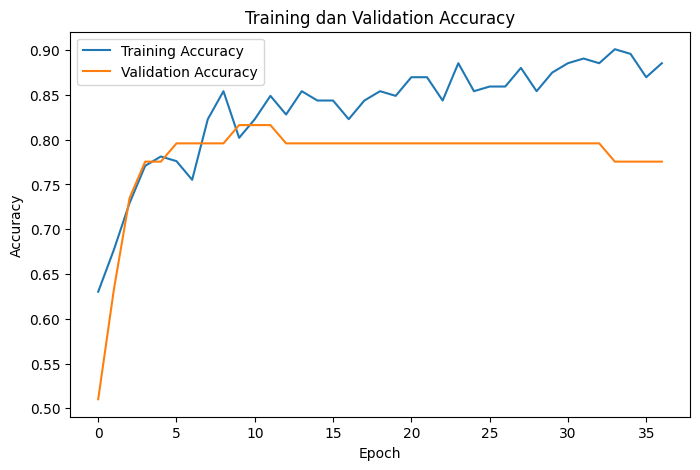

In [7]:
# =========================================================
# 6. Grafik Training dan Validation Accuracy
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training dan Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

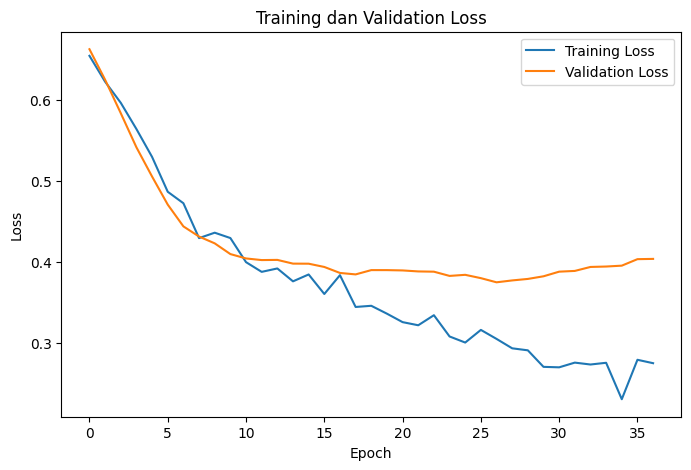

In [8]:
# =========================================================
# 7. Grafik Training dan Validation Loss
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
# =========================================================
# 8. Menyimpan Model
# =========================================================

model_path1 = "model"
model_path2 = "../model"

if os.path.exists("../processed_data"):
    model_folder = model_path2
else:
    model_folder = model_path1

os.makedirs(model_folder, exist_ok=True)

model.save(f"{model_folder}/heart_disease_nn_model.h5")

print("Model berhasil disimpan.")
print("Lokasi model:", f"{model_folder}/heart_disease_nn_model.h5")

Model berhasil disimpan.
Lokasi model: ../model/heart_disease_nn_model.h5


In [10]:
# =========================================================
# 9. Penanda Selesai
# =========================================================

print("[READY] Indhira Done - Model Neural Network selesai dilatih")

[READY] Indhira Done - Model Neural Network selesai dilatih
